===============================================

🔐 CICIDS2017 Multi-Class Hacking Attack Prediction Model

===============================================


In [53]:
# ================================
# Mount Drive
# ================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
# ================================
# Import Libraries
# ================================
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, log_loss, roc_auc_score, matthews_corrcoef
from sklearn.utils.class_weight import compute_class_weight

In [55]:
# ================================
# Load & Merge Dataset
# ================================
datasetPath = [
    "/content/drive/MyDrive/AI_Project/dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "/content/drive/MyDrive/AI_Project/dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "/content/drive/MyDrive/AI_Project/dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "/content/drive/MyDrive/AI_Project/dataset/Monday-WorkingHours.pcap_ISCX.csv",
    "/content/drive/MyDrive/AI_Project/dataset/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "/content/drive/MyDrive/AI_Project/dataset/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "/content/drive/MyDrive/AI_Project/dataset/Tuesday-WorkingHours.pcap_ISCX.csv",
    "/content/drive/MyDrive/AI_Project/dataset/Wednesday-workingHours.pcap_ISCX.csv"
]

datasetList = [pd.read_csv(file) for file in datasetPath]
dataset = pd.concat(datasetList, ignore_index=True)

print("Original shape:", dataset.shape)

Original shape: (2830743, 79)


In [56]:
# ================================
# FIX COLUMN NAMES & CLEAN
# ================================
dataset.columns = dataset.columns.str.strip()
dataset = dataset.replace([np.inf, -np.inf], np.nan)
dataset = dataset.dropna()

print("After cleaning:", dataset.shape)

After cleaning: (2827876, 79)


In [57]:
# ================================
# Randow 10 data
# ================================
random10 = dataset.sample(n=10, random_state=42)
random10.to_csv("/content/drive/MyDrive/AI_Project/artifacts/sample_dataset/random10_data.csv", index=False)

In [58]:
# ================================
# BALANCE DATASET
# ================================
# This custom function handles both majority (undersampling) and minority (oversampling/duplicating) classes
counts = dataset["Label"].value_counts()
print("\nOriginal Class Distribution:\n", counts)

def balance_data(df, target_size=5000):
    balanced_df = pd.DataFrame()
    for label in df['Label'].unique():
        class_df = df[df['Label'] == label]
        if len(class_df) >= target_size:
            # Undersample majority classes
            sampled = class_df.sample(n=target_size, random_state=42, replace=False)
        else:
            # Oversample (duplicate) minority classes
            sampled = class_df.sample(n=target_size, random_state=42, replace=True)
        balanced_df = pd.concat([balanced_df, sampled])
    return balanced_df.reset_index(drop=True)

dataset = balance_data(dataset)

print("\nBalanced shape:", dataset.shape)
print("Balanced Class Distribution:\n", dataset["Label"].value_counts())


Original Class Distribution:
 Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Balanced shape: (75000, 79)
Balanced Class Distribution:
 Label
BENIGN                        5000
DDoS                          5000
PortScan                      5000
Bot                           5000
Infiltration                  5000
Web Attack � Brute Force      5000
Web Attack � XSS              5000
Web Attack � Sql Injection    5000
FTP-Patator           

In [59]:
# ================================
# Features & Target
# ================================
X = dataset.drop("Label", axis=1)
Y = dataset["Label"]

print("Features shape:", X.shape)
print("Target shape:", Y.shape)

Features shape: (75000, 78)
Target shape: (75000,)


In [60]:
# ================================
# Encode Labels
# ================================
le = LabelEncoder()
Y = le.fit_transform(Y)

print("Classes:", le.classes_)

Classes: ['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']


In [61]:
# ================================
# Train Test Split
# ================================
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

In [62]:
# ================================
# Randow 10 preprocess data
# ================================
randow10 = dataset.sample(n=10, random_state=42)
randow10.to_csv("/content/drive/MyDrive/AI_Project/artifacts/sample_dataset/randow10_preprocess_data.csv", index=False)

In [63]:
# ================================
# Feature Scaling
# ================================
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [64]:
# ================================
# Randow 10 preprocess data after scaling
# ================================
randow10 = pd.DataFrame(X_train)
randow10 = randow10.sample(n=10, random_state=42)
randow10.to_csv("/content/drive/MyDrive/AI_Project/artifacts/sample_dataset/randow10_preprocess_data_after_scaling.csv", index=False)

In [65]:
# ================================
# CLASS WEIGHTS
# ================================
# Note: Since the classes are now perfectly balanced at 5000, these will all evaluate to 1.0.
# It is kept here in case you change your balancing strategy later.
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y_train),
    y=Y_train
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0), 8: np.float64(1.0), 9: np.float64(1.0), 10: np.float64(1.0), 11: np.float64(1.0), 12: np.float64(1.0), 13: np.float64(1.0), 14: np.float64(1.0)}


In [66]:
# ================================
# ANN Model
# ================================
ann = tf.keras.models.Sequential()

# Input layer + Hidden Layer 1
ann.add(tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
ann.add(tf.keras.layers.BatchNormalization())
ann.add(tf.keras.layers.Dropout(0.3))

# Hidden Layer 2
ann.add(tf.keras.layers.Dense(64, activation='relu'))
ann.add(tf.keras.layers.BatchNormalization())
ann.add(tf.keras.layers.Dropout(0.3))

# Hidden Layer 3
ann.add(tf.keras.layers.Dense(32, activation='relu'))
ann.add(tf.keras.layers.BatchNormalization())

# Output Layer
ann.add(tf.keras.layers.Dense(len(np.unique(Y)), activation='softmax'))

# ================================
# Compile
# ================================
ann.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [67]:
# ================================
# Callbacks
# ================================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=30, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6
    )
]


In [68]:
# ================================
# Train
# ================================
history = ann.fit(
    X_train,
    Y_train,
    validation_split=0.2,
    epochs=1000,
    batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks,  # <-- Activated Callbacks
    verbose=1
)

Epoch 1/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7648 - loss: 0.7281 - val_accuracy: 0.8683 - val_loss: 0.3149 - learning_rate: 0.0010
Epoch 2/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8531 - loss: 0.3643 - val_accuracy: 0.8783 - val_loss: 0.2597 - learning_rate: 0.0010
Epoch 3/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8676 - loss: 0.3140 - val_accuracy: 0.8803 - val_loss: 0.2390 - learning_rate: 0.0010
Epoch 4/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8721 - loss: 0.2945 - val_accuracy: 0.8684 - val_loss: 0.2288 - learning_rate: 0.0010
Epoch 5/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8745 - loss: 0.2798 - val_accuracy: 0.8954 - val_loss: 0.2159 - learning_rate: 0.0010
Epoch 6/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8776 - loss: 0.2662 - val_accuracy: 0.8957 - val_loss: 0.2229 - learning_rate: 0.0010
Epoch 7/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8812 - l

In [69]:
# ================================
# Prediction & Evaluation
# ================================
Y_prob = ann.predict(X_test)
Y_pred = np.argmax(Y_prob, axis=1)

# Convert back to labels
Y_test_labels = le.inverse_transform(Y_test)
Y_pred_labels = le.inverse_transform(Y_pred)

print("Y_test : ", Y_test_labels)
print("Y_pred : ", Y_pred_labels)

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Y_test :  ['BENIGN' 'FTP-Patator' 'FTP-Patator' ... 'Web Attack � XSS'
 'Web Attack � Sql Injection' 'SSH-Patator']
Y_pred :  ['BENIGN' 'FTP-Patator' 'FTP-Patator' ... 'Web Attack � XSS'
 'Web Attack � Sql Injection' 'SSH-Patator']


In [70]:
# ================================
# Confusion Matrix, Accuracy, Classification Report
# ================================
print("\n--- Model Evaluation Details ---")
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("Log Loss:", log_loss(Y_test, Y_prob))
print("ROC AUC (OVR):", roc_auc_score(Y_test, Y_prob, multi_class='ovr'))
print("Matthews Correlation Coefficient:", matthews_corrcoef(Y_test, Y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))


--- Model Evaluation Details ---
Accuracy: 0.9477333333333333
Log Loss: 0.12045618352481818
ROC AUC (OVR): 0.9967291142857142
Matthews Correlation Coefficient: 0.9446928624015603

Confusion Matrix:
 [[ 952   16    6    2    5    0    2    0    0    5    9    1    0    0
     2]
 [   1  999    0    0    0    0    0    0    0    0    0    0    0    0
     0]
 [   0    0 1000    0    0    0    0    0    0    0    0    0    0    0
     0]
 [   0    0    0  991    0    0    0    0    0    0    0    0    0    9
     0]
 [   0    0    0    0  999    0    0    0    0    0    0    0    0    1
     0]
 [   3    0    0    0    0  991    5    0    0    0    0    0    0    1
     0]
 [   0    0    0    1    1    4  992    0    0    0    0    0    0    1
     1]
 [   0    0    0    0    1    0    3  995    0    0    0    1    0    0
     0]
 [   0    0    0    0    0    0    0    0 1000    0    0    0    0    0
     0]
 [   0    0    0    0    0    0    0    0    0 1000    0    0    0    0
     0]


In [71]:
# ================================
# SAVE RESULTS (NO FOLDER CREATION NEEDED)
# ================================
import pandas as pd

save_path = "/content/drive/MyDrive/AI_Project/artifacts/reports"

# Save metrics
with open(f"{save_path}/metrics.txt", "w") as f:
    f.write("--- Model Evaluation Details ---\n")
    f.write(f"Accuracy: {accuracy_score(Y_test, Y_pred)}\n")
    f.write(f"Log Loss: {log_loss(Y_test, Y_prob)}\n")
    f.write(f"ROC AUC (OVR): {roc_auc_score(Y_test, Y_prob, multi_class='ovr')}\n")
    f.write(f"Matthews Correlation Coefficient: {matthews_corrcoef(Y_test, Y_pred)}\n\n")

    f.write("Confusion Matrix:\n")
    f.write(str(confusion_matrix(Y_test, Y_pred)) + "\n\n")

    f.write("Classification Report:\n")
    f.write(classification_report(Y_test, Y_pred))

# Save confusion matrix CSV
cm = confusion_matrix(Y_test, Y_pred)
pd.DataFrame(cm, index=le.classes_, columns=le.classes_) \
  .to_csv(f"{save_path}/confusion_matrix.csv")

print("✅ Metrics saved successfully!")

✅ Metrics saved successfully!


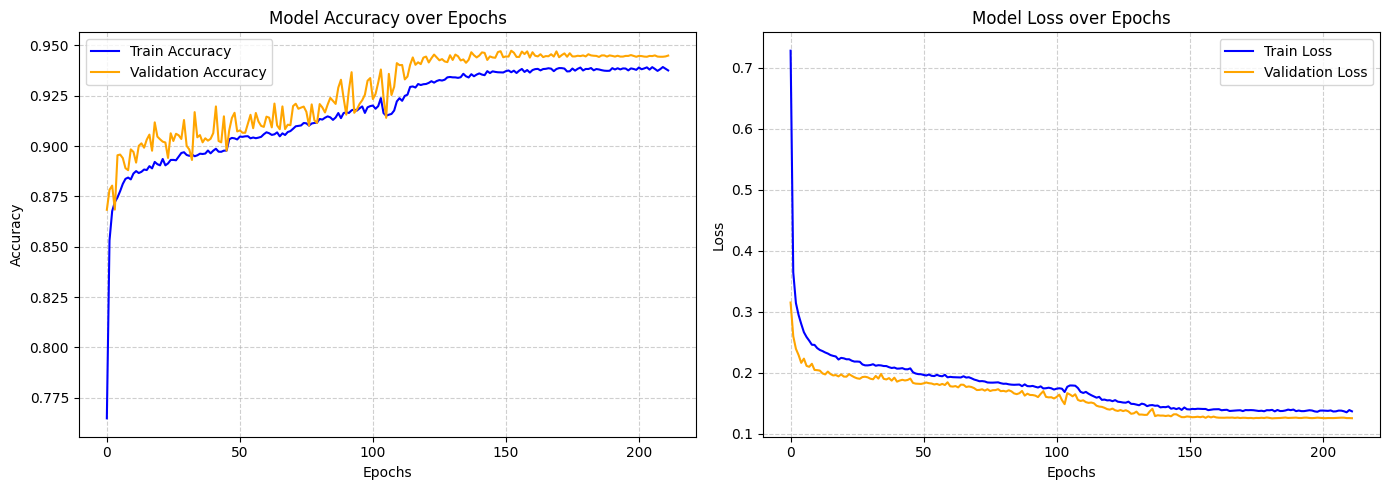

In [72]:
import matplotlib.pyplot as plt

# Create a figure with two subplots (side-by-side)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax[0].set_title('Model Accuracy over Epochs')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

# Plot Loss
ax[1].plot(history.history['loss'], label='Train Loss', color='blue')
ax[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax[1].set_title('Model Loss over Epochs')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(f"{save_path}/training_plot.png")
plt.show()

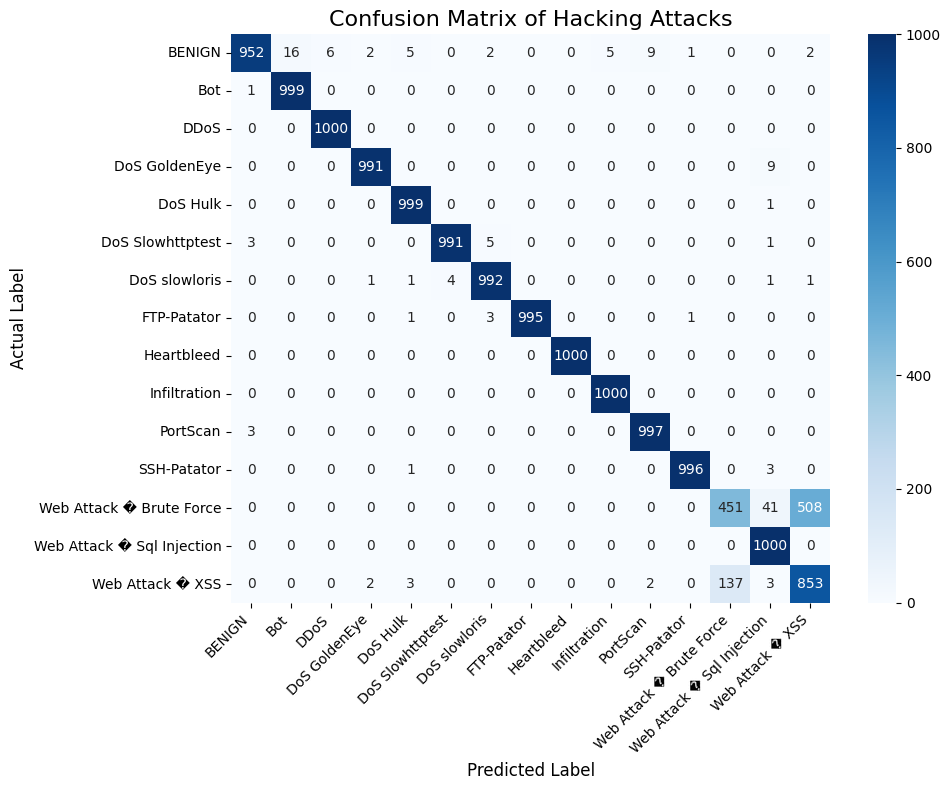

In [73]:
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(Y_test, Y_pred)

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.title('Confusion Matrix of Hacking Attacks', fontsize=16)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels so they fit

plt.tight_layout()
plt.savefig(f"{save_path}/confusion_matrix.png")
plt.show()

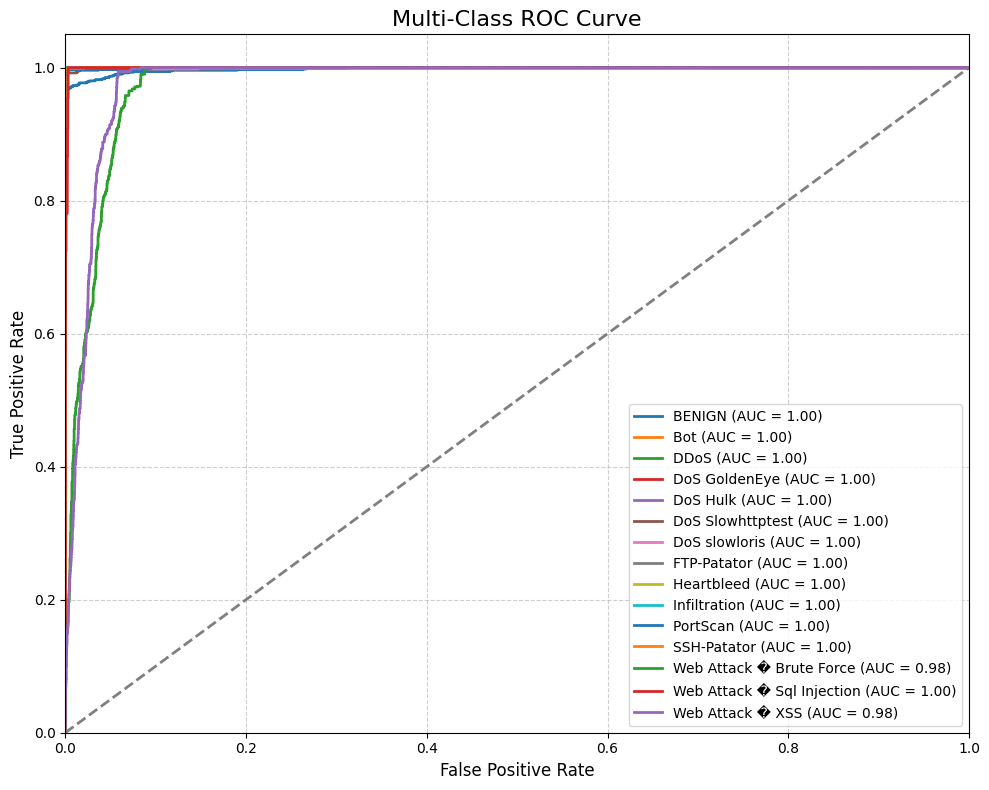

In [74]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the output for multi-class ROC calculation
Y_test_bin = label_binarize(Y_test, classes=range(len(le.classes_)))

plt.figure(figsize=(10, 8))

# Calculate and plot the ROC curve for each class
for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(Y_test_bin[:, i], Y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{le.classes_[i]} (AUC = {roc_auc:.2f})')

# Plot the diagonal 50% guessing line
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multi-Class ROC Curve', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(f"{save_path}/roc_curve.png")
plt.show()

In [75]:
# ================================
# Save Model & Tools
# ================================

save_path = "/content/drive/MyDrive/AI_Project/artifacts/model"

ann.save(f"{save_path}/hacking_attack_prediction_model.h5")
joblib.dump(sc, f"{save_path}/scaler.pkl")
joblib.dump(le, f"{save_path}/label_encoder.pkl")

print("✅ Model & Tools saved successfully!")

✅ Model & Tools saved successfully!


In [77]:
# ================================
# Manual Prediction Test
# ================================
from tensorflow.keras.models import load_model

# Load saved files

save_path = "/content/drive/MyDrive/AI_Project/artifacts/model"

model = load_model(f"{save_path}/hacking_attack_prediction_model.h5")
le = joblib.load(f"{save_path}/label_encoder.pkl")

# Grab a sample that is ALREADY scaled from our X_test array
input_row = 978
sample_scaled = X_test[input_row:input_row + 1]

# Get actual label (Use index to get scalar value)
actual_class = Y_test[input_row]

# Predict
prediction = model.predict(sample_scaled)
pred_class = np.argmax(prediction, axis=1)

# Decode both
pred_label = le.inverse_transform(pred_class)[0]
actual_label = le.inverse_transform([actual_class])[0]

print("🚨 Predicted:", pred_label)
print("✅ Actual:", actual_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
🚨 Predicted: DoS Hulk
✅ Actual: DoS Hulk
